In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os
import csv
import pandas as pd

import scipy.stats
from sklearn.linear_model import LinearRegression

import torch
from networks_update import Encoder, Decoder
import math
import random

### Synth data generation performance eval pipeline:

1. Plot loss
2. Plot slices of a couple translation - to observe approx stucture maintainment
3. Plot gm/wm/gm distributions of the real train and test versus generated test
4. Plot the variance in the real test set and generated test
    - look for mode collapse and run previous visualization proc is observed
5. Plot the wm/gm/csf ratio of real and genreated pairs, maybe plot the differences?

In [2]:
# Calculation helper functions
def get_matter_ratio(img_arr):
    gm_count = np.sum(img_arr == 1)
    wm_count = np.sum(img_arr == 2)
    csf_count = np.sum(img_arr == 3)
    total = gm_count + wm_count + csf_count

    gm_ratio = gm_count/total
    wm_ratio = wm_count/total
    csf_ratio = csf_count/total

    return gm_ratio, wm_ratio, csf_ratio


def compute_matter_ratios(folder_path):
    gm_ratios = []
    wm_ratios = []
    csf_ratios = []

    folder_list = os.listdir(folder_path)
    folder_list.sort()

    for file_name in folder_list:
        img = sitk.ReadImage(folder_path + file_name)
        img_arr = sitk.GetArrayFromImage(img)

        gm_ratio, wm_ratio, csf_ratio = get_matter_ratio(img_arr)

        gm_ratios.append(gm_ratio)
        wm_ratios.append(wm_ratio)
        csf_ratios.append(csf_ratio)

    return gm_ratios, wm_ratios, csf_ratios


def compute_voxelwise_variance(folder_path, skip=np.empty(0)):
    img_stack = []

    for i, file_name in enumerate(os.listdir(folder_path)):
        # skip any flagged files (assume read in same order)
        if not skip.any() or not skip[i]:
            img_arr = sitk.GetArrayFromImage(sitk.ReadImage(folder_path + file_name))
            img_stack.append(img_arr)

    img_stack = np.stack(img_stack, axis=0)

    # claculate variance on each set of voxel values for every voxel
    voxel_variance = np.var(img_stack, axis=0)

    return voxel_variance


# Plotting helper functions
def plot_matter_ratios(gm_ratios, wm_ratios, csf_ratios, title, bins=50):
    print("mean gm:", round(np.mean(gm_ratios), 4), "var:", round(np.var(gm_ratios), 8))
    plt.figure(figsize=(5,4))
    plt.hist(gm_ratios, bins, edgecolor="darkorchid", color="mediumorchid")
    plt.xlabel("Grey matter ratio")
    plt.ylabel("Frequency")
    plt.title(title + " grey matter ratio")
    plt.show()

    print("mean wm:", round(np.mean(wm_ratios), 4), "var:", round(np.var(wm_ratios), 8))
    plt.figure(figsize=(5,4))
    plt.hist(wm_ratios, bins, edgecolor="darkslategrey", color="darkcyan")
    plt.xlabel("White matter ratio")
    plt.ylabel("Frequency")
    plt.title(title + " white matter ratio")
    plt.show()

    print("mean csf:", round(np.mean(csf_ratios), 4), "var:", round(np.var(csf_ratios), 8))
    plt.figure(figsize=(5,4))
    plt.hist(csf_ratios, bins, edgecolor="seagreen", color="mediumseagreen")
    plt.xlabel("CSF ratio")
    plt.ylabel("Frequency")
    plt.title(title + " CSF ratio")
    plt.show()

def plot_img(img_arr, slice_idx, title="", cmap="gray"):
    plt.figure(figsize=(2,2))
    plt.imshow(img_arr[slice_idx, :, :], cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()

def analyze_matter_ratio_preservation(real, synth, title, color):
    # i) Run pearson correlation analysis
    #   - r = measures the linear correlation between two variables
    #   - r = cov(x, y) / (std_x*std_y)
    #   - r = +1 => perfect possitve correlation
    #   - r = -1 => perfect negative correlation
    #   - r = 0 => no correlation
    # The p tests the null hypothesis that there is no correlation between the two
    # variables (p < 0.05 => significant corr, p > 0.05 => correlation could be chance)
    r, p = scipy.stats.pearsonr(real, synth)
    print(f"Pearson's r: {round(r, 4)}, p-value: {round(p, 4)}")

    # ii) Compute coefficent of determination (R^2)
    #   - give the variance of dependent y explained by the independent variable x
    #   - R^2 = 1 - (sum [y_true - y_pred]^2)/(sum [y_true - y_mean]^2)
    #   - R^2 = 1 => perfect prediction
    #   - R^2 = 0 => model explains none of the variance
    #   - R^2 < 0 => model is a bad fit
    real_reshape = np.array(real).reshape(-1, 1)
    synth_reshape = np.array(synth).reshape(-1, 1)
    model = LinearRegression().fit(real_reshape, synth_reshape)
    r_squared = model.score(real_reshape, synth_reshape)
    print(f"R²: {round(r_squared, 4)}")

    model.fit(real_reshape, synth)

    # Predict y values for the regressed line
    y_pred = model.predict(real_reshape)

    # iii) Plot the real versus reconstructed with fitted line overlayed
    plt.figure(figsize=(4,4))
    plt.scatter(real, synth, color=color, s=10)
    plt.plot(real, y_pred, color="black")
    plt.xlabel("Real ratio")
    plt.ylabel("Synth ratio")
    plt.title(title)
    plt.show()

def cross_entropy_loss_from_logits(y_pred_probs, y_true_class_indices, eps=1e-12):
    # Clip predicted probabilities to avoid log(0)
    y_pred_probs = np.clip(y_pred_probs, eps, 1. - eps)
    
    # Extract the predicted probability for the correct class
    correct_class_probs = y_pred_probs[np.arange(len(y_true_class_indices)), y_true_class_indices]
    
    # Compute the average negative log likelihood
    return -np.mean(np.log(correct_class_probs))

## Synth data generation analysis

500


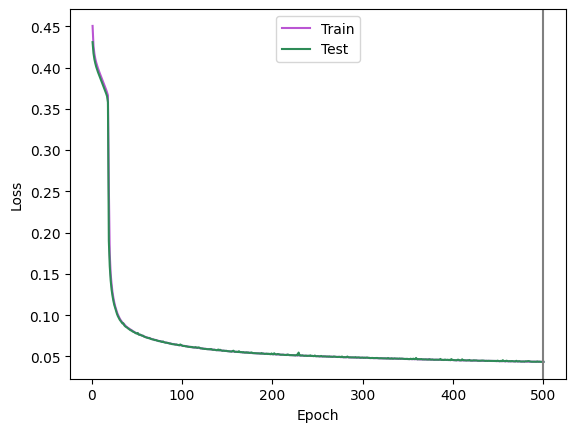

In [ ]:
# 1. Plot loss
loss = pd.read_csv("./save_models/mouse_train_5/loss_log.csv")
#test_loss = pd.read_csv("./save_models/human_train_1/test_loss_log.csv")

min_test = loss.iloc[:, 0][np.argmin(loss.iloc[:, 2])]
print(min_test)

plt.figure()
plt.plot(loss.iloc[:, 0], loss.iloc[:, 1], color="mediumorchid")
plt.plot(loss.iloc[:, 0], loss.iloc[:, 2], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.show()

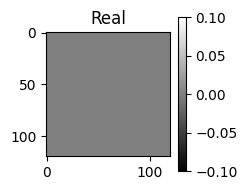

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

<Figure size 200x200 with 0 Axes>

In [13]:
# 2. Plot a couple of the images saved during training
idx = 0 # 0, 1, 3 (only saved for first 3 image in folder)
train_save_folder = "./save_models/mouse_train_5/"
epoch = 500
slices = [30, 40, 60, 70]

test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]
test_paths.sort()

truth_img = sitk.GetArrayFromImage(sitk.ReadImage(test_paths[idx]))
recon_img = sitk.GetArrayFromImage(sitk.ReadImage(train_save_folder + "test_images/recon_" + test_paths[idx].split("/")[-1].split(".")[0] + "_epoch_" + str(epoch) + ".nii"))
recon_img = recon_img[1]
for slice_idx in slices:
    plot_img(truth_img, slice_idx, "Real")
    plot_img(recon_img, slice_idx, "Reconstructed")



truth path: ../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/images/BRM19070_02_RARE_labels_GMWM.nii
recon path: ./save_translations/train_5_map_6/trans_BRM19070_02_RARE_labels_GMWM.nii
idx: 1
MSE: 0.3797
Mean accuracy: 79.97%
real gm: 0.897 recon gm: 0.6018
real wm: 0.0898 recon wm: 0.351
real csf: 0.0132 recon csf: 0.0472


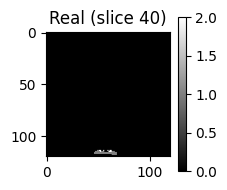

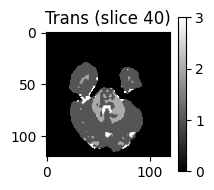

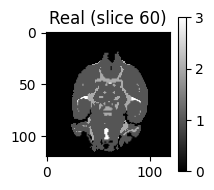

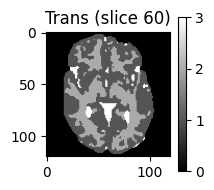

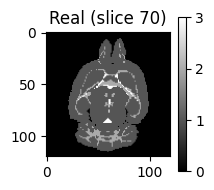

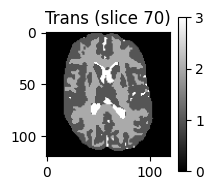

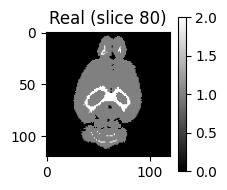

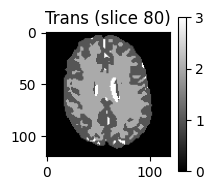

In [9]:
# 2. Plot some reconstructions (Plot the reconstructed images during testing)
idx = 1 # 0 - 55?
recon_img_folder = "./save_translations/train_5_map_6/"
recon_paths = [recon_img_folder + file_name for file_name in os.listdir(recon_img_folder)]
recon_paths.sort()

slices = [40, 60, 70, 80]

test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]
test_paths.sort()

print("truth path:", test_paths[idx])
print("recon path:", recon_paths[idx])

truth_img = sitk.GetArrayFromImage(sitk.ReadImage(test_paths[idx]))
recon_img = sitk.GetArrayFromImage(sitk.ReadImage(recon_paths[idx]))

# mse of reconstruction
mse = round(np.mean((truth_img - recon_img)**2), 4)
acc = np.mean(truth_img == recon_img)

real_gm_ratio, real_wm_ratio, real_csf_ratio = get_matter_ratio(truth_img)
recon_gm_ratio, recon_wm_ratio, recon_csf_ratio = get_matter_ratio(recon_img)

print("idx:", idx)
print("MSE:", mse)
print("Mean accuracy:", str(np.round(acc, 4)*100) + "%")

print("real gm:", round(real_gm_ratio, 4), "recon gm:", round(recon_gm_ratio, 4))
print("real wm:", round(real_wm_ratio, 4), "recon wm:", round(recon_wm_ratio, 4))
print("real csf:", round(real_csf_ratio, 4), "recon csf:", round(recon_csf_ratio, 4))

for slice_idx in slices:
   plot_img(truth_img, slice_idx, "Real (slice " + str(slice_idx) + ")")
   plot_img(recon_img, slice_idx, "Trans (slice " + str(slice_idx) + ")")

mean gm: 0.5939 var: 2.369e-05


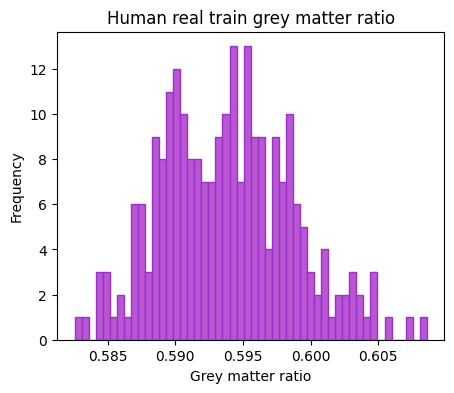

mean wm: 0.3559 var: 2.536e-05


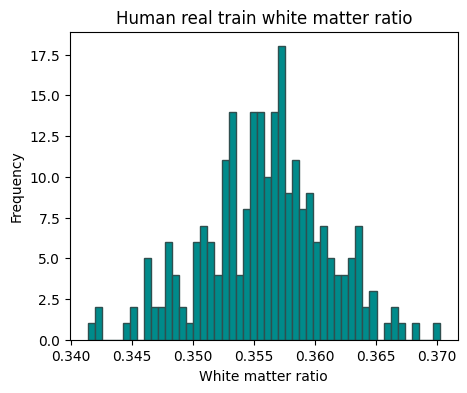

mean csf: 0.0502 var: 4.74e-06


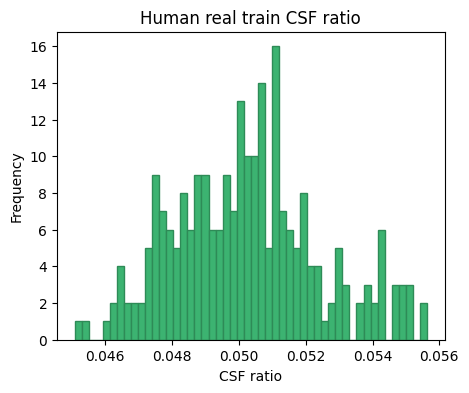

mean gm: 0.5952 var: 2.912e-05


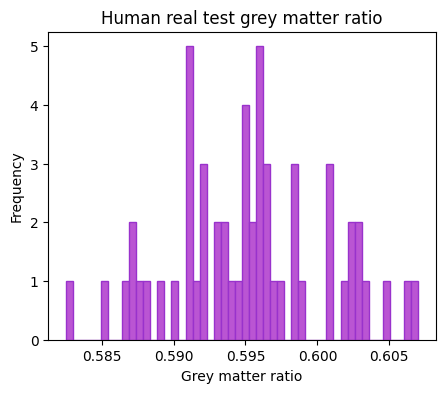

mean wm: 0.3548 var: 3.251e-05


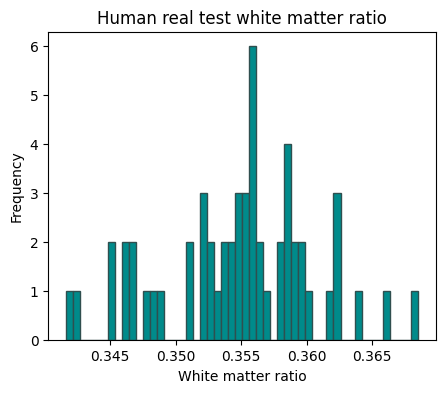

mean csf: 0.0499 var: 5.19e-06


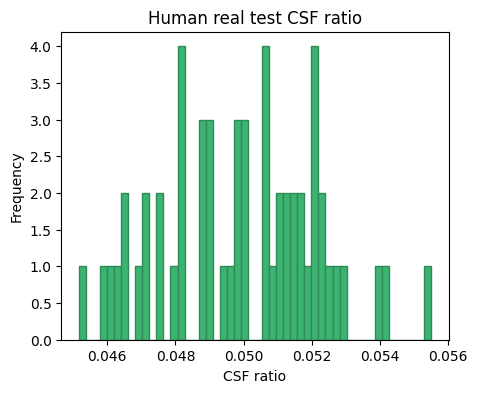

mean gm: 0.6331 var: 0.00014303


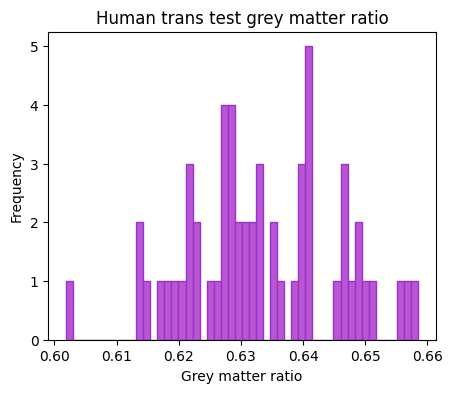

mean wm: 0.3271 var: 0.00011941


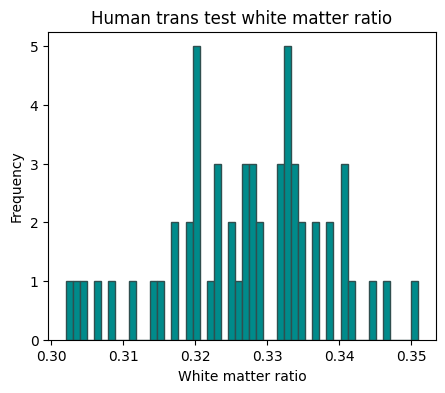

mean csf: 0.0398 var: 7.67e-06


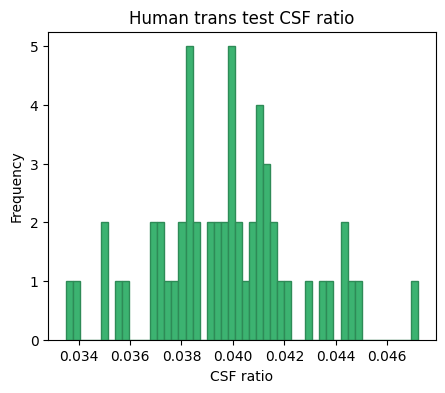

In [11]:
# 3. Plot gm/wm/csf ratios
real_train_data_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/labels/"
real_test_data_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/labels/"

synth_test_data_folder = "./save_translations/train_5_map_6/"

real_train_gm, real_train_wm, real_train_csf = compute_matter_ratios(real_train_data_folder)
plot_matter_ratios(real_train_gm, real_train_wm, real_train_csf, "Human real train")

real_test_gm, real_test_wm, real_test_csf = compute_matter_ratios(real_test_data_folder)
plot_matter_ratios(real_test_gm, real_test_wm, real_test_csf, "Human real test")

synth_test_gm, synth_test_wm, synth_test_csf = compute_matter_ratios(synth_test_data_folder)
plot_matter_ratios(synth_test_gm, synth_test_wm, synth_test_csf, "Human trans test")

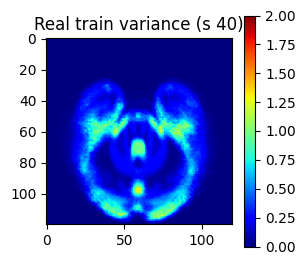

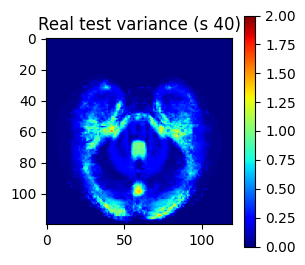

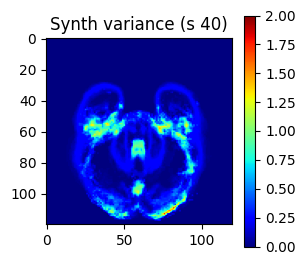

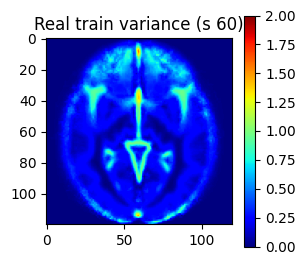

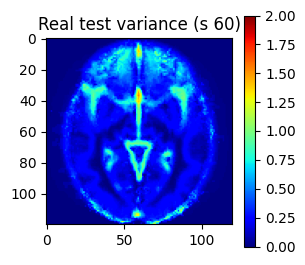

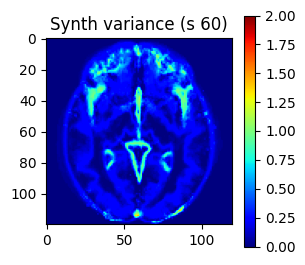

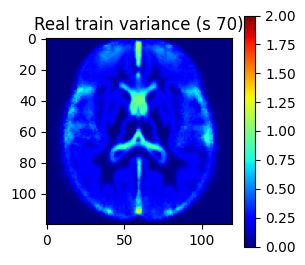

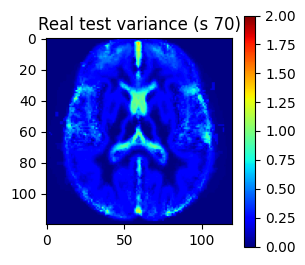

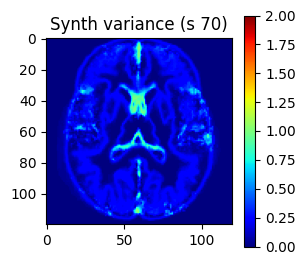

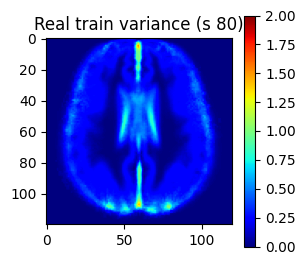

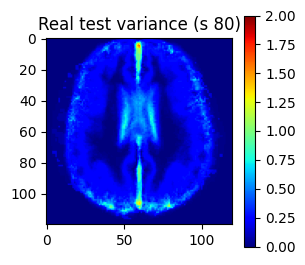

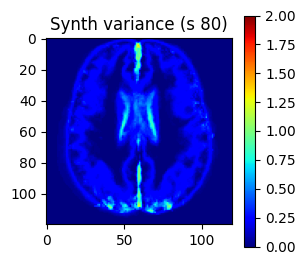

In [13]:
# 4. Calculate variance of train, test, and recon datasets
real_train_voxel_variance = sitk.GetImageFromArray(compute_voxelwise_variance(real_train_data_folder))
real_test_voxel_variance = sitk.GetImageFromArray(compute_voxelwise_variance(real_test_data_folder))
synth_test_voxel_variance = sitk.GetImageFromArray(compute_voxelwise_variance(synth_test_data_folder))

# save the variance images
#sitk.WriteImage(real_train_voxel_variance, "./save_models/human_train_1/real_train_voxel_variance.nii")
#sitk.WriteImage(real_test_voxel_variance, "./save_models/human_train_1/real_test_voxel_variance.nii")
#sitk.WriteImage(synth_test_voxel_variance, "./save_models/human_train_1/synth_test_voxel_variance.nii")

slices = [40, 60, 70, 80]


def plot_img(img_arr, slice_idx, title="", cmap="gray"):
    plt.figure(figsize=(3,3))
    plt.imshow(img_arr[slice_idx, :, :], cmap, vmin=0, vmax=2)
    plt.title(title)
    plt.colorbar()
    plt.show()

for slice_idx in slices:
    plot_img(sitk.GetArrayFromImage(real_train_voxel_variance), slice_idx, "Real train variance (s " + str(slice_idx) + ")", cmap="jet")
    plot_img(sitk.GetArrayFromImage(real_test_voxel_variance), slice_idx, "Real test variance (s " + str(slice_idx) + ")", cmap="jet")
    plot_img(sitk.GetArrayFromImage(synth_test_voxel_variance), slice_idx, "Synth variance (s " + str(slice_idx) + ")", cmap="jet")

Pearson's r: -0.048, p-value: 0.7254
R²: 0.0023


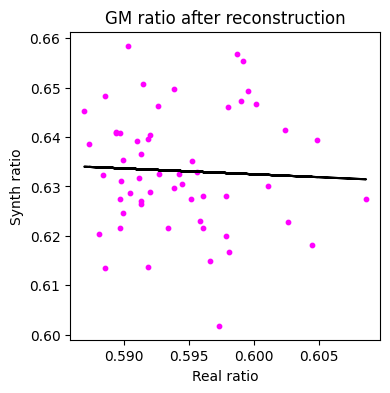

Pearson's r: -0.0722, p-value: 0.5972
R²: 0.0052


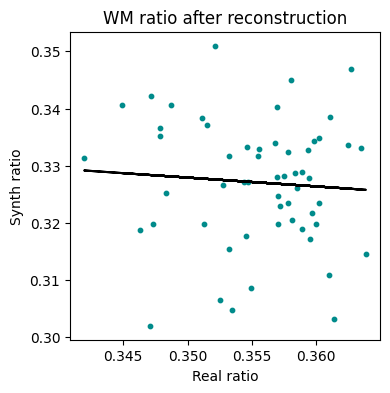

Pearson's r: 0.148, p-value: 0.2765
R²: 0.0219


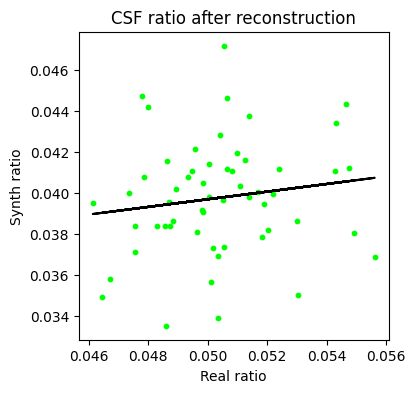

In [14]:
# 5. Look into if the gm/wm/csf ratios are preserved in reconstruction

analyze_matter_ratio_preservation(real_train_gm[:56], synth_test_gm, "GM ratio after reconstruction", "magenta")
analyze_matter_ratio_preservation(real_train_wm[:56], synth_test_wm, "WM ratio after reconstruction", "darkcyan")
analyze_matter_ratio_preservation(real_train_csf[:56], synth_test_csf, "CSF ratio after reconstruction", "lime")
